# Classificação de Reclamações Financeiras e Análise das Dores dos Clientes

Nesse Tech Challenge o desafio é construir um modelo de Deep Learning capaz de classificar automaticamente o sentimento das reclamações de clientes (positivas ou negativas) com base no texto enviado, e realizar uma análise das principais dores relatadas em cada categoria de produto financeiro.

Temos em mãos um conjunto de dados com reclamações de consumidores sobre produtos e serviços financeiros, contendo o texto da reclamação, a empresa envolvida e a categoria do produto/serviço (como cartão de crédito, hipoteca, empréstimo, etc.). Essas reclamações foram encaminhadas às empresas e publicadas após confirmação de relacionamento comercial. Agora, devemos ajudar a entender melhor como os consumidores se sentem em relação a esses serviços e quais problemas são mais recorrentes.

Base de Dados: https://www.kaggle.com/datasets/shashwatwork/consume-complaints-dataset-fo-nlp?resource=download

## 1 Importação das Bibliotecas

In [1]:
#!pip install pandas matplotlib seaborn scikit-learn "numpy<2.0" nltk xgboost tensorflow keras torch keras-nlp gensim fasttext

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction import DictVectorizer  # usado para o Bag of Words
from sklearn.feature_extraction.text import TfidfVectorizer  # usado para o TF-IDF
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [4]:
import re

In [5]:
# etapas necessárias para o download de recursos do nltk
import nltk

nltk.download("punkt_tab")  # é utilizado para tokenização
nltk.download("stopwords")  # é utilizado para remoção de stopwords
nltk.download("rslp")  # é utilizado para stemização

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


True

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

In [7]:
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

In [8]:
#  apenas para tipagem de variáveis no Matplotlib
fig: Figure
ax: Axes
axs: list[Axes]

In [9]:
sns.set_style("darkgrid")

In [10]:

from wordcloud import WordCloud

## 2 Aquisição, Exploração e Tratamento dos Dados

###2.1 Carregamento dos Dados

In [91]:
df = pd.read_csv("/content/complaints_processed.csv", usecols=['product', 'narrative'])

In [92]:
df.head()

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


### 2.2 Análise Exploratória dos Dados

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    162421 non-null  object
 1   narrative  162411 non-null  object
dtypes: object(2)
memory usage: 2.5+ MB


In [94]:
print(f"Total de produtos listados na coluna 'product': {df['product'].nunique()}")
print(df['product'].unique())

Total de produtos listados na coluna 'product': 5
['credit_card' 'retail_banking' 'credit_reporting' 'mortgages_and_loans'
 'debt_collection']


Eliminando linhas com "narrative" nulo

In [95]:
df.narrative.apply(lambda x: isinstance(x, str)).all()

np.False_

In [96]:
empty_narrative_rows = df[df['narrative'].isnull()]
display(empty_narrative_rows)

,product,narrative
1089,credit_reporting,NaN
3954,credit_reporting,NaN
3955,credit_reporting,NaN
29690,credit_reporting,NaN
139436,debt_collection,NaN
151052,debt_collection,NaN
154494,credit_reporting,NaN
156902,retail_banking,NaN
158538,credit_reporting,NaN
159503,credit_reporting,NaN


In [97]:
df.dropna(subset=['narrative'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162411 entries, 0 to 162420
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    162411 non-null  object
 1   narrative  162411 non-null  object
dtypes: object(2)
memory usage: 3.7+ MB


Verificando e eliminando linhas duplicadas, colunas narrative e product idênticas

In [98]:
duplicadas = df[df.duplicated(subset=['narrative', 'product'], keep=False)]
display(duplicadas.sort_values(by=['narrative', 'product']))
print(f"Total de linhas duplicadas (narrative e product): {duplicadas.shape[0]}")

,product,narrative
2500,debt_collection,aargon collection agency result identity theft...
2503,debt_collection,aargon collection agency result identity theft...
2506,debt_collection,aargon collection agency result identity theft...
31570,retail_banking,able link account
148060,retail_banking,able link account
...,...,...
63103,credit_reporting,yet receive type response credit reporting age...
63104,credit_reporting,yet receive type response credit reporting age...
63105,credit_reporting,yet receive type response credit reporting age...
114378,retail_banking,zelled expecting product previously assumption...


Total de linhas duplicadas (narrative e product): 50033


In [99]:
df.drop_duplicates(subset=['narrative', 'product'], inplace=True)
df.info()
print(f"Linhas restantes após remover duplicatas: {df.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 124676 entries, 0 to 162420
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    124676 non-null  object
 1   narrative  124676 non-null  object
dtypes: object(2)
memory usage: 2.9+ MB
Linhas restantes após remover duplicatas: 124676


##3 Tokenização

Iniciaremos os passos de Feature Engineering para preparar os dados para treinamento pelo modelo.
A primeira etapa deste processo é a **tokenização**, onde dividiremos o texto em palavras ou frases menores, chamadas de tokens.

In [100]:
# aplica a tokenização em todos os textos da coluna narrative
df["tokens"] = df.narrative.apply(word_tokenize)
df.info()
print(f"Coluna narrative tokenizada e salva na coluna tokens.")

<class 'pandas.core.frame.DataFrame'>
Index: 124676 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    124676 non-null  object
 1   narrative  124676 non-null  object
 2   tokens     124676 non-null  object
dtypes: object(3)
memory usage: 3.8+ MB
Coluna narrative tokenizada e salva na coluna tokens.


##4 Limpeza de Dados

### 4.1 Lowercasing (transformar  todos os tokens na coluna 'tokens' para letras minúsculas para padronização)

In [101]:
df["tokens"] = df["tokens"].apply(lambda x: [token.lower() for token in x])
print("Todos os tokens na coluna 'tokens' foram convertidos para minúsculas.")

Todos os tokens na coluna 'tokens' foram convertidos para minúsculas.


### 4.2 Remoção de Pontuação e Caracteres Especiais

In [102]:
def remove_pontuacao_especial_chars(tokens):
    cleaned_tokens = []
    for token in tokens:
        # Removendo qualquer caractere que não seja alfanumerico
        cleaned_token = re.sub(r'[^a-zA-Z0-9]', '', token)
        if cleaned_token: # Manter apenas se o token não estiver vazio após limpeza
            cleaned_tokens.append(cleaned_token)
    return cleaned_tokens

df["tokens"] = df["tokens"].apply(remove_pontuacao_especial_chars)
print("Pontuações e caracteres especiais removidos dos tokens.")

Pontuações e caracteres especiais removidos dos tokens.


### 4.3 Remoção de Stopwords
Remover palavras irrelevantes (stopwords) dos tokens para reduzir o ruído e focar nas palavras mais significativas para a análise.

In [103]:
print(nltk.corpus.stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [104]:
english_stopwords = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in english_stopwords]

df["tokens"] = df["tokens"].apply(remove_stopwords)
print("Stopwords em ingles removidas dos tokens.")

Stopwords em ingles removidas dos tokens.


### 4.4 Aplicar Stemming (Radicalização / Stemização)

Aplicar stemming (radicalização) aos tokens na coluna 'tokens' para reduzir as palavras à sua raiz, padronizando-as e facilitando a análise.

In [105]:
stemmer = RSLPStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(token) for token in tokens]

df["tokens_st"] = df["tokens"].apply(apply_stemming)
print("Stemming aplicado aos tokens.")

Stemming aplicado aos tokens.


### 4.5 Verificação - Exibiçao das 5 primeiras linhas


In [106]:
df.head()

,product,narrative,tokens,tokens_st
0,credit_card,purchase order day shipping amount receive pro...,"[purchase, order, day, shipping, amount, recei...","[purchas, ord, day, shipping, amount, receiv, ..."
1,credit_card,forwarded message date tue subject please inve...,"[forwarded, message, date, tue, subject, pleas...","[forwarded, messag, dat, tue, subject, pleas, ..."
2,retail_banking,forwarded message cc sent friday pdt subject f...,"[forwarded, message, cc, sent, friday, pdt, su...","[forwarded, messag, cc, sent, friday, pdt, sub..."
3,credit_reporting,payment history missing credit report speciali...,"[payment, history, missing, credit, report, sp...","[payment, history, missing, credit, report, sp..."
4,credit_reporting,payment history missing credit report made mis...,"[payment, history, missing, credit, report, ma...","[payment, history, missing, credit, report, ma..."


### 4.6 Avaliando o Dataset Limpo e Processado

Palavras mais frequentes

In [107]:
counter_tk = Counter()

df.tokens_st.apply(counter_tk.update)

n = 20
counter_df = pd.DataFrame(
    counter_tk.most_common(n),
    columns=["tokens", "count"],
)

counter_df.head()

,tokens,count
0,account,252931
1,credit,239647
2,report,124538
3,payment,118365
4,information,104300


##5 Criação da Variável Alvo - y target

Após limpeza dos dados, devemos definir uma variável alvo, ou seja, se as avaliações são positivas (1) ou negativas (0)

### 5.1 Método 1 - Manual por palavras chaves

#### 5.1.1 Definindo Palavras-Chave de Sentimento
Criaremos uma lista de keywords para sentimentos negativos e positivos, garantindo que estejam stematizadas para identificação nas avaliações. Em seguida, criaremos uma função para classificar o sentimento ('Negativo' ou 'Positivo') baseado nestas keywords, priorizando termos negativos.

In [108]:
negative_keywords = [
    'complaint', 'bad', 'dissatisfaction', 'difficulty', 'error', 'delay',
    'cancel', 'deceive', 'fraud', 'lose', 'undue charge', 'unresolved',
    'ignore', 'harm', 'disappointed', 'terrible', 'slow', 'unfair', 'misleading',
    'abusive', 'refusal', 'deny', 'threat', 'disrespect', 'bad faith', 'failure',
    'incompetent', 'unbearable', 'unacceptable', 'inconvenient', 'dispute',
    'litigation', 'non-compliance'
]

positive_keywords = [
    'resolve', 'help', 'solve', 'thank', 'excellent', 'good', 'satisfied',
    'fast', 'efficient', 'appreciate', 'understand', 'available', 'clarify',
    'support', 'trust', 'improve', 'correct', 'compensate', 'refund',
    'returned', 'work', 'facilitate', 'attentive', 'courteous', 'willing',
    'support', 'success', 'successful', 'progress', 'transparency', 'clarity',
    'assistance', 'guidance'
]

stemmed_negative_keywords = [stemmer.stem(word) for word in negative_keywords]
stemmed_positive_keywords = [stemmer.stem(word) for word in positive_keywords]

print("Negative keywords defined and stemmed.")
print("Positive keywords defined and stemmed.")

print("\nExample stemmed negative keywords:", stemmed_negative_keywords[:5])
print("Example stemmed positive keywords:", stemmed_positive_keywords[:5])

Negative keywords defined and stemmed.
Positive keywords defined and stemmed.

Example stemmed negative keywords: ['complaint', 'bad', 'dissatisfaction', 'difficulty', 'err']
Example stemmed positive keywords: ['resolv', 'help', 'solv', 'thank', 'excellent']


#### 5.1.2 Classificação das Opiniões
Com os tokens de sentimento stematizados, criaremoas a função `classify_sentiment` que verificará presença desta lista nas avaliações reais e classificará como positiva, negativa ou neutra. Será priorizado o sentimento negativo.

In [109]:
def classify_sentiment(tokens):
    has_negative = any(word in stemmed_negative_keywords for word in tokens)
    has_positive = any(word in stemmed_positive_keywords for word in tokens)

    if has_negative:
        return 'Negativa'
    elif has_positive:
        return 'Positiva'
    else:
        return 'Neutro'

df['sentimento'] = df['tokens_st'].apply(classify_sentiment)
print("Classificação do Sentimento, tokens stemizados, aplicando na coluna 'tokens_st'")

Classificação do Sentimento, tokens stemizados, aplicando na coluna 'tokens_st'


In [110]:
sentiment_distribution = df['sentimento'].value_counts()
print("Classificação do sentiment0 (tokens_st):")
print(sentiment_distribution)

Classificação do sentiment0 (tokens_st):
sentimento
Negativa    60095
Neutro      40931
Positiva    23650
Name: count, dtype: int64


In [111]:
df.head()

,product,narrative,tokens,tokens_st,sentimento
0,credit_card,purchase order day shipping amount receive pro...,"[purchase, order, day, shipping, amount, recei...","[purchas, ord, day, shipping, amount, receiv, ...",Negativa
1,credit_card,forwarded message date tue subject please inve...,"[forwarded, message, date, tue, subject, pleas...","[forwarded, messag, dat, tue, subject, pleas, ...",Positiva
2,retail_banking,forwarded message cc sent friday pdt subject f...,"[forwarded, message, cc, sent, friday, pdt, su...","[forwarded, messag, cc, sent, friday, pdt, sub...",Negativa
3,credit_reporting,payment history missing credit report speciali...,"[payment, history, missing, credit, report, sp...","[payment, history, missing, credit, report, sp...",Negativa
4,credit_reporting,payment history missing credit report made mis...,"[payment, history, missing, credit, report, ma...","[payment, history, missing, credit, report, ma...",Negativa


####5.1.3 Analisando os Neutros
Iremos filtras as opiniôes neutras e verificar termos que podem ser adicionados aos keywords positivos ou negativos.

In [112]:
neutral_complaints_df = df[df['sentimento'] == 'Neutro']
neutral_complaints_df.head()

,product,narrative,tokens,tokens_st,sentimento
11,credit_card,called request new york state covid relief pla...,"[called, request, new, york, state, covid, rel...","[called, request, new, york, stat, covid, reli...",Neutro
12,credit_card,capital one secured credit account opened name...,"[capital, one, secured, credit, account, opene...","[capit, one, secured, credit, account, opened,...",Neutro
13,credit_reporting,collection account acct opened balance account...,"[collection, account, acct, opened, balance, a...","[collection, account, acct, opened, balanc, ac...",Neutro
15,mortgages_and_loans,current loan provident funding applied refinan...,"[current, loan, provident, funding, applied, r...","[current, loan, provident, funding, applied, r...",Neutro
19,credit_reporting,xxxxxxxx credit card year disputed charge vend...,"[xxxxxxxx, credit, card, year, disputed, charg...","[xxxxxxxx, credit, card, ye, disputed, charg, ...",Neutro


In [113]:
all_neutral_tokens = [token for sublist in neutral_complaints_df['tokens_st'] for token in sublist]

neutral_token_counts = Counter(all_neutral_tokens)

print("Top 20 palavras mais comuns nas reclamações neutras:")
for token, count in neutral_token_counts.most_common(20):
    print(f"{token}: {count}")

Top 20 palavras mais comuns nas reclamações neutras:
account: 55121
credit: 50431
report: 29943
payment: 19064
information: 15503
debt: 15188
company: 14371
loan: 11901
inquiry: 11571
reporting: 11558
tim: 11028
nev: 10923
card: 10549
dat: 10424
received: 9820
bank: 9743
lett: 9359
collection: 8959
lat: 8834
would: 8719


In [114]:
print("Palavras comuns nas reclamações neutras:")
for token, count in reversed(neutral_token_counts.most_common()[:100]):
    print(f"{token}: {count}")

Palavras comuns nas reclamações neutras:
document: 2996
know: 3021
statement: 3049
contact: 3073
financ: 3074
immediately: 3080
violation: 3127
act: 3159
new: 3181
send: 3210
interest: 3224
without: 3226
email: 3254
requested: 3273
mak: 3281
check: 3307
open: 3321
car: 3336
well: 3357
sever: 3383
could: 3448
orig: 3585
last: 3586
consum: 3599
even: 3613
scor: 3630
min: 3688
experian: 3708
fee: 3772
provid: 3791
proof: 3810
request: 3936
person: 3956
sinc: 4035
fil: 4093
bill: 4099
addres: 4127
charg: 4155
asked: 4205
contacted: 4313
need: 4364
agency: 4384
phon: 4530
inaccurat: 4588
credi: 4603
closed: 4661
money: 4665
said: 4696
theft: 4726
it: 4779
serv: 4846
mortgag: 5324
back: 5325
fraudulent: 5359
mad: 5478
pay: 5516
ye: 5581
get: 5681
one: 5686
opened: 5781
identity: 5852
removed: 5938
als: 6077
bureau: 6085
still: 6235
nam: 6313
reported: 6596
due: 6665
pleas: 6824
month: 6836
amount: 6996
call: 7130
called: 7223
remov: 7625
told: 7749
paid: 7931
numb: 8434
sent: 8469
day: 8527


Palavras identificadas para inclusão nas keywords:

Positive: well, immediately, interest, experian

Negative: violation, fraudulent, inaccurat, theft

#### 5.1.3 Adição de novas palavras para classificação
Incluímos as palavras que identificamos como possívels de classificar nos neutros e em seguida, aplicamos novamente  função `classify_sentiment` .

In [115]:
negative_keywords_add = [
    'complaint', 'bad', 'dissatisfaction', 'difficulty', 'error', 'delay',
    'cancel', 'deceive', 'fraud', 'lose', 'undue charge', 'unresolved',
    'ignore', 'harm', 'disappointed', 'terrible', 'slow', 'unfair', 'misleading',
    'abusive', 'refusal', 'deny', 'threat', 'disrespect', 'bad faith', 'failure',
    'incompetent', 'unbearable', 'unacceptable', 'inconvenient', 'dispute',
    'litigation', 'non-compliance', 'violation', 'fraudulent', 'inaccurate', 'theft'
]

positive_keywords_add = [
    'resolve', 'help', 'solve', 'thank', 'excellent', 'good', 'satisfied',
    'fast', 'efficient', 'appreciate', 'understand', 'available', 'clarify',
    'support', 'trust', 'improve', 'correct', 'compensate', 'refund',
    'returned', 'work', 'facilitate', 'attentive', 'courteous', 'willing',
    'support', 'success', 'successful', 'progress', 'transparency', 'clarity',
    'assistance', 'guidance', 'well', 'immediately', 'interest', 'experian'
]

stemmed_negative_keywords = [stemmer.stem(word) for word in negative_keywords_add]
stemmed_positive_keywords = [stemmer.stem(word) for word in positive_keywords_add]

In [116]:
df['sentimento'] = df['tokens_st'].apply(classify_sentiment)
print("Classificação do sentiment0 (tokens_st) - inclusão de novas palavras")

Classificação do sentiment0 (tokens_st) - inclusão de novas palavras


In [117]:
sentiment_distribution = df['sentimento'].value_counts()
print("Classificação do sentimento:")
print(sentiment_distribution)

Classificação do sentimento:
sentimento
Negativa    73264
Neutro      25791
Positiva    25621
Name: count, dtype: int64


In [118]:
#pd.set_option('display.max_colwidth', None)

print('--- Reclamações Negativas (Primeiras 5 linhas - Conteúdo Completo) ---')
display(df[df['sentimento'] == 'Negativa']['narrative'].head().to_frame())

print('\n--- Reclamações Positivas (Primeiras 5 linhas - Conteúdo Completo) ---')
display(df[df['sentimento'] == 'Positiva']['narrative'].head().to_frame())

print('\n--- Reclamações Neutras (Primeiras 5 linhas - Conteúdo Completo) ---')
display(df[df['sentimento'] == 'Neutro']['narrative'].head().to_frame())

--- Reclamações Negativas (Primeiras 5 linhas - Conteúdo Completo) ---


,narrative
0,purchase order day shipping amount receive pro...
2,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...
4,payment history missing credit report made mis...
5,payment history missing credit report made mis...



--- Reclamações Positivas (Primeiras 5 linhas - Conteúdo Completo) ---


,narrative
1,forwarded message date tue subject please inve...
11,called request new york state covid relief pla...
14,collection agency system inc mn phone sent let...
15,current loan provident funding applied refinan...
19,xxxxxxxx credit card year disputed charge vend...



--- Reclamações Neutras (Primeiras 5 linhas - Conteúdo Completo) ---


,narrative
12,capital one secured credit account opened name...
13,collection account acct opened balance account...
42,open account acct opened balance account acct ...
43,open account acct opened balance account acct ...
46,signed lease company called illinois end lease...


#### 5.1.4 Proporção de cada categoria

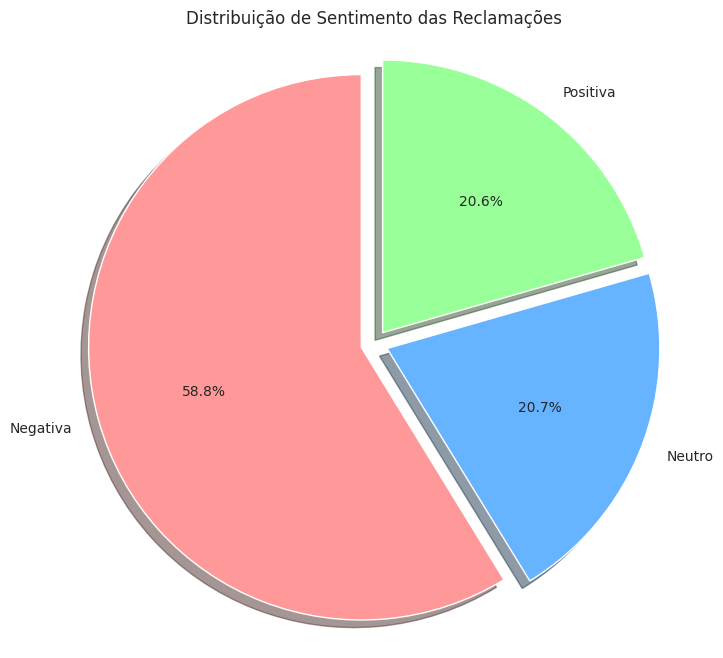

In [119]:
import matplotlib.pyplot as plt

labels = sentiment_distribution.index
sizes = sentiment_distribution.values
colors = ['#ff9999','#66b3ff','#99ff99'] # Light colors for each slice
explode = (0.05, 0.05, 0.05)  # Explode a slice if desired

fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Distribuição de Sentimento das Reclamações')
plt.show()

###5.2 Uso da função TextBlob


Analisa a polaridade da frase para verificar se é positiva ou negativa

####5.2.1 União dos tokens em formato de unica String
Será necessário usar desta forma para TF-IDF e TextBlob

In [120]:
df['narrative_processed'] = df['tokens'].apply(lambda x: ' '.join(x))
print("Coluna 'narrative_processed' criada com sucesso.")

Coluna 'narrative_processed' criada com sucesso.


####5.2.2 Analisando Sentimento com TextBlob - Texto Processado sem Stematização
Uso do texto processado e stematizado pode ser prejudicial ao modelo. A eficiência do TextBlob diminui se usamos uma base limpa, pois ele depende do contexto estrutural da frase para máxima precisão.


In [121]:
# Instalar a biblioteca TextBlob
!pip install textblob

print("TextBlob instalado com sucesso.")

TextBlob instalado com sucesso.


In [122]:
from textblob import TextBlob

def get_sentiment(text):
  analysis = TextBlob(text)
  if analysis.sentiment.polarity > 0:
    return 'Positiva'
  elif analysis.sentiment.polarity < 0:
    return 'Negativa'
  else:
    return 'Neutro'

In [123]:
df['sentimento_textblob'] = df['narrative_processed'].apply(get_sentiment)
print("Classificação dos Sentimentos com uso de TextBlob aplicado a coluna narrative_processed")
sentiment_distribution_textblob = df['sentimento_textblob'].value_counts()
print("Distribuição de Sentimentos com TextBlob:")
print(sentiment_distribution_textblob)

Classificação dos Sentimentos com uso de TextBlob aplicado a coluna narrative_processed
Distribuição de Sentimentos com TextBlob:
sentimento_textblob
Positiva    59960
Negativa    48873
Neutro      15843
Name: count, dtype: int64


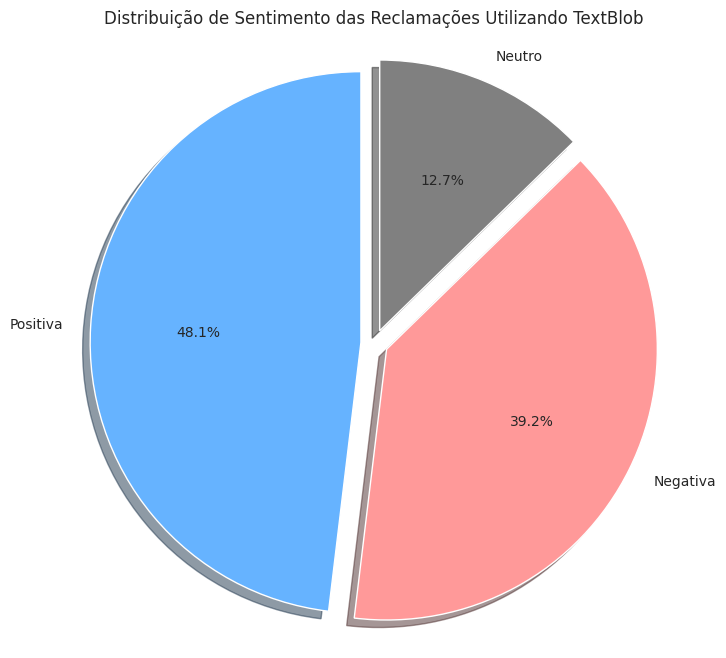

In [125]:
labels = sentiment_distribution_textblob.index
sizes = sentiment_distribution_textblob.values
colors = ['#66b3ff','#ff9999','#808080']
explode = (0.05, 0.05, 0.05)
#ff9999 vermelho ; #66b3ff azul; #99ff99 verde; #ffffed amarelo claro; #ffff00 amarelo, #808080 cinza;
fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')

plt.title('Distribuição de Sentimento das Reclamações Utilizando TextBlob')
plt.show()

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124676 entries, 0 to 162420
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   product              124676 non-null  object
 1   narrative            124676 non-null  object
 2   tokens               124676 non-null  object
 3   tokens_st            124676 non-null  object
 4   sentimento           124676 non-null  object
 5   narrative_processed  124676 non-null  object
 6   sentimento_textblob  124676 non-null  object
dtypes: object(7)
memory usage: 7.6+ MB


### 5.3 Coluna Sentimento (Positivo Negativo)
### Positiva = 1; Negativa = 0
Criaremos a coluna sentimento positivo e negativo a partir da coluna 'sentimento_textblob_texto', pois esta apresentou menor quantidade de neutros.
Para nossa análise, os neutros serão excluídos.

In [127]:
df_label=df[df['sentimento_textblob'] != 'Neutro'].copy()
df_label['label'] = df_label['sentimento_textblob'].map({'Positiva': 1, 'Negativa': 0})
df_label = df_label[['product', 'tokens', 'narrative_processed', 'sentimento_textblob', 'label']]
df_label.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108833 entries, 0 to 162414
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   product              108833 non-null  object
 1   tokens               108833 non-null  object
 2   narrative_processed  108833 non-null  object
 3   sentimento_textblob  108833 non-null  object
 4   label                108833 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 5.0+ MB


In [128]:
df_label.head()

,product,tokens,narrative_processed,sentimento_textblob,label
0,credit_card,"[purchase, order, day, shipping, amount, recei...",purchase order day shipping amount receive pro...,Positiva,1
1,credit_card,"[forwarded, message, date, tue, subject, pleas...",forwarded message date tue subject please inve...,Negativa,0
2,retail_banking,"[forwarded, message, cc, sent, friday, pdt, su...",forwarded message cc sent friday pdt subject f...,Negativa,0
3,credit_reporting,"[payment, history, missing, credit, report, sp...",payment history missing credit report speciali...,Positiva,1
4,credit_reporting,"[payment, history, missing, credit, report, ma...",payment history missing credit report made mis...,Positiva,1


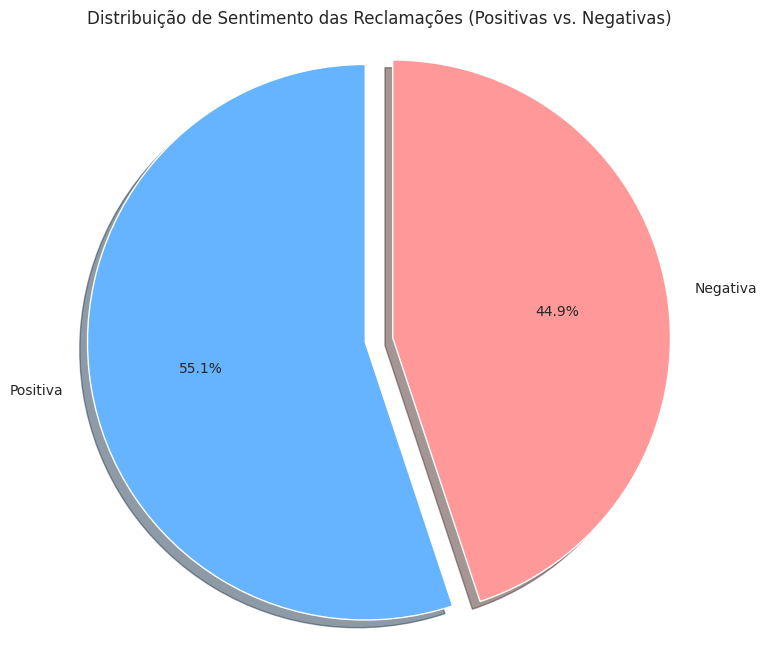

In [129]:
sentiment_counts = df_label['label'].value_counts()

labels = ['Positiva', 'Negativa']
sizes = [sentiment_counts.get(1, 0), sentiment_counts.get(0, 0)]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)

fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Distribuição de Sentimento das Reclamações (Positivas vs. Negativas)')
plt.show()

## 6 Bag of Words (BoW)

Iremos portanto criar uma representação chamada de Bag of Words, que consiste em contar a frequência de cada palavra em cada texto, criando uma matriz em que cada linha representa um texto e cada coluna representa uma palavra.
Usaremos os dados stemizados.

In [130]:
individual_counter = df.tokens_st.apply(Counter)
individual_counter.head()

,tokens_st
0,"{'purchas': 5, 'ord': 13, 'day': 2, 'shipping'..."
1,"{'forwarded': 1, 'messag': 1, 'dat': 1, 'tue':..."
2,"{'forwarded': 1, 'messag': 1, 'cc': 1, 'sent':..."
3,"{'payment': 6, 'history': 5, 'missing': 4, 'cr..."
4,"{'payment': 6, 'history': 5, 'missing': 4, 'cr..."


##7 Vetorização TF-IDF
Com a coluna 'narrative_processed' já criada, iremos utilizar `TfidfVectorizer` e aplicar `fit_transform()` para converter o texto para a matriz TF-IDF.



In [131]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df_label['narrative_processed'])
print("TF-IDF vectorization applied successfully. Shape of X_tfidf:")
print(X_tfidf.shape)

TF-IDF vectorization applied successfully. Shape of X_tfidf:
(108833, 44853)


In [132]:
y = df_label['label']
print("Target variavel 'y' definida como coluna 'label'")

Target variavel 'y' definida como coluna 'label'


Com `X_tfidf` (features) e `y` (target) definidos, separaremos os dados em treino e teste usando  `train_test_split` para preparar dados de treino e teste



In [133]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.3, random_state=42, stratify=y)
print("Divisão de dados em treino e teste realizada")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Divisão de dados em treino e teste realizada
X_train shape: (76183, 44853)
X_test shape: (32650, 44853)
y_train shape: (76183,)
y_test shape: (32650,)


##8 Modelo Classificação Naive Bayes

Treino, teste e avaliação da performance

In [134]:
mnb_classifier = MultinomialNB()
mnb_classifier.fit(X_train, y_train)
print("Multinomial Naive Bayes classifier trained successfully.")

Multinomial Naive Bayes classifier trained successfully.


In [135]:
y_pred = mnb_classifier.predict(X_test)
print("Classification Report - Multinomial Naive Bayes:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix - Multinomial Naive Bayes:")
print(confusion_matrix(y_test, y_pred))

Classification Report - Multinomial Naive Bayes:
              precision    recall  f1-score   support

           0       0.87      0.48      0.62     14662
           1       0.69      0.94      0.80     17988

    accuracy                           0.73     32650
   macro avg       0.78      0.71      0.71     32650
weighted avg       0.77      0.73      0.71     32650

Confusion Matrix - Multinomial Naive Bayes:
[[ 6981  7681]
 [ 1035 16953]]


In [136]:
def plot_confusion_matrix(true_labels, predictions):
    """
    Plots a confusion matrix using Seaborn's heatmap.
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    fig: Figure
    ax: Axes
    cm = 100 * confusion_matrix(true_labels, predictions, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"format": "%.0f%%"})

    # Custom function to format the annotations as percentages
    for text in ax.texts:
        text.set_text(f"{float(text.get_text()):.1f}%")

    ax.set_xlabel("Predicted labels")
    ax.set_ylabel("True labels")
    ax.set_title("Confusion Matrix")
    ax.xaxis.set_tick_params(rotation=0)
    ax.yaxis.set_tick_params(rotation=0)
    fig.set_tight_layout(True)
    plt.show()

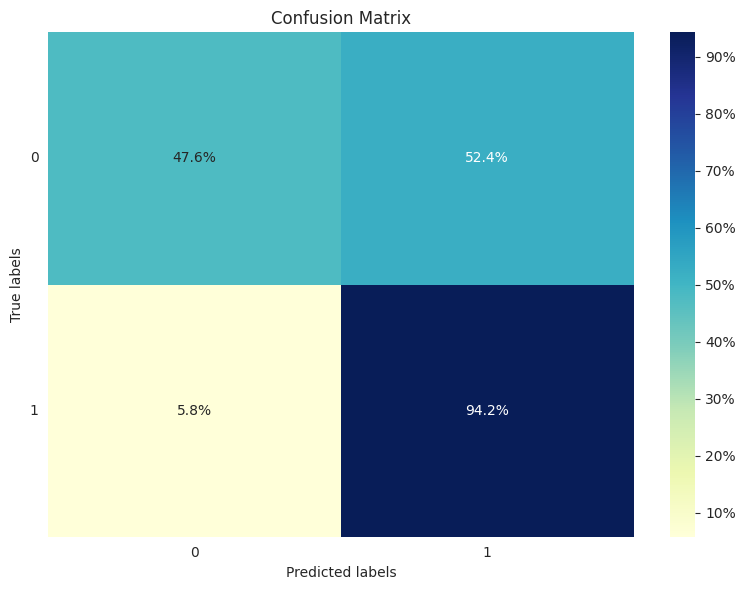

In [137]:
plot_confusion_matrix(y_test, y_pred)

## 9 Modelo XG Boost

In [138]:
xgb_class = XGBClassifier()
xgb_class = XGBClassifier().fit(X_train, y_train)
print("XGB classifier trained successfully.")

XGB classifier trained successfully.


In [139]:
y_pred_xgb = xgb_class.predict(X_test)
print("Classification Report - XGB Classifier:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix - XGB Classifier:")
print(confusion_matrix(y_test, y_pred_xgb))

Classification Report - XGB Classifier:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88     14662
           1       0.89      0.92      0.90     17988

    accuracy                           0.89     32650
   macro avg       0.89      0.89      0.89     32650
weighted avg       0.89      0.89      0.89     32650

Confusion Matrix - XGB Classifier:
[[12510  2152]
 [ 1361 16627]]


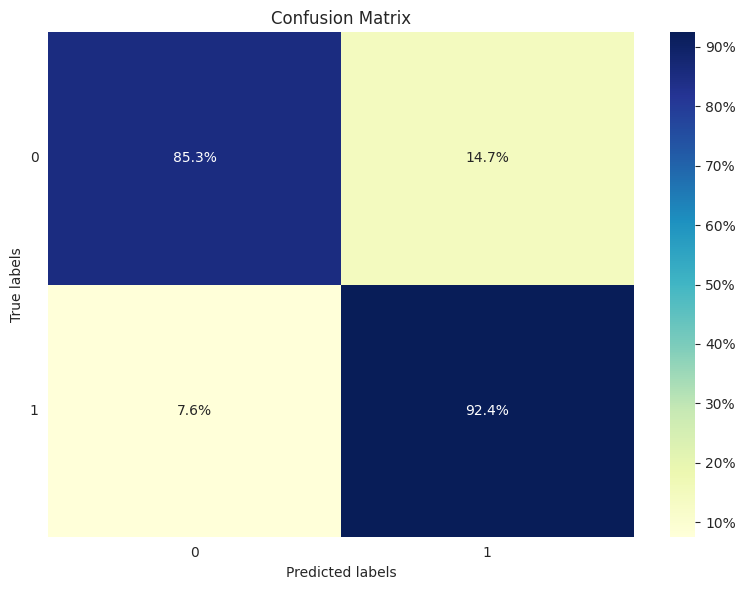

In [140]:
plot_confusion_matrix(y_test, y_pred_xgb)

##10 Deep Learning

###10.1 Preparo dos dados e treinamento
Utilizaremos o `Tokenizer` do Keras para transformar os textos da coluna `narrative_processed` em sequências de inteiros e, em seguida, preencher (pad) essas sequências para garantir que todas tenham o mesmo comprimento, tornando-as adequadas para a entrada de um modelo de Deep Learning.

In [141]:
# Install keras-preprocessing package if not already installed
!pip install keras-preprocessing

print("keras-preprocessing installed successfully.")

keras-preprocessing installed successfully.


In [142]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Tokenizer and pad_sequences imported successfully from tensorflow.keras.")

Tokenizer and pad_sequences imported successfully from tensorflow.keras.


Iniciaremos o `Tokenizer` com `num_words=10000` para preparar para treinamento dos dados.



In [143]:
tokenizer = Tokenizer(num_words=10000, oov_token="<unk>")
print("Tokenizer inicializado com: num_words=10000.")

Tokenizer inicializado com: num_words=10000.


In [144]:
tokenizer.fit_on_texts(df_label['narrative_processed'])
print("Tokenizer treinado na 'narrative_processed' coluna.")

Tokenizer treinado na 'narrative_processed' coluna.


Com `Tokenizer` treindado, usaremos o método `texts_to_sequences()` para converter o texto processado em sequencias numéricad para uso de Deep Learning models.



In [145]:
X_sequences = tokenizer.texts_to_sequences(df_label['narrative_processed'])
print("Texts converted to sequences of integers.")

Texts converted to sequences of integers.


Agora, iremos padronizar `X_sequences` para comprimento uniforme usando `pad_sequences` do `tensorflow.keras.preprocessing.sequence`, specificamente `maxlen` e `dtype=np.int32` para evitar problemas de compatibilidade.



In [146]:
import numpy as np

max_sequence_len = int(pd.Series([len(x) for x in X_sequences]).median())
X_padded = pad_sequences(X_sequences, maxlen=max_sequence_len, padding='post', truncating='post', dtype=np.int32)
print(f"Sequences padded to a maximum length of {max_sequence_len}. Shape of X_padded: {X_padded.shape}")

Sequences padded to a maximum length of 66. Shape of X_padded: (108833, 66)


In [147]:
y_target = np.array(df_label['label'])
print(f"Variável target 'y_target' criada, shape: {y_target.shape}")

Variável target 'y_target' criada, shape: (108833,)


###10.2 Dividindo Dados de Treino e Teste com Estratificação

Divisão do dataset em conjuntos de treino e teste, garantindo um embaralhamento (shuffle) adequado e utilizando estratificação para manter proporções semelhantes de sentimentos positivos e negativos em ambos os conjuntos.


In [148]:
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_target, test_size=0.2, random_state=42, stratify=y_target)

print("Dados divididos em conjuntos de treino e teste com estratificação.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dados divididos em conjuntos de treino e teste com estratificação.
X_train shape: (87066, 66)
X_test shape: (21767, 66)
y_train shape: (87066,)
y_test shape: (21767,)


###10.3 Construção do Modelo de Deep Learning

Definir a arquitetura do modelo de Deep Learning usando Keras, incluindo camadas de Embedding, GlobalAveragePooling1D e Dense. Em seguida, compilar o modelo com uma função de perda e otimizador adequados para classificação binária.


In [149]:
vocab_size = tokenizer.num_words + 1

# Criando o modelo
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_sequence_len),
    GlobalAveragePooling1D(),
    Dense(1, activation='sigmoid')
])

# Compilando o modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Modelo de Deep Learning criado e compilado com sucesso.")
model.summary()

Modelo de Deep Learning criado e compilado com sucesso.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Neste modelo usaremos um batch size de 32, 10 epochs. Após diversas verificações, foi a combinação mais eficaz do ponto de vista desempenho X tempo de processamento

Batch Size - velocidade de treinamento / Epochs numero de vezes que o algoritmo trabalhará com o conjunto de dados de treinamento.



In [150]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))
print("Modelo de Deep Learning treinado com sucesso.")

Epoch 1/10
2721/2721 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.7187 - loss: 0.5412 - val_accuracy: 0.8431 - val_loss: 0.3863
Epoch 2/10
2721/2721 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8590 - loss: 0.3535 - val_accuracy: 0.8551 - val_loss: 0.3696
Epoch 3/10
2721/2721 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8775 - loss: 0.3248 - val_accuracy: 0.8539 - val_loss: 0.3687
Epoch 4/10
2721/2721 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8775 - loss: 0.3185 - val_accuracy: 0.8415 - val_loss: 0.3798
Epoch 5/10
2721/2721 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8830 - loss: 0.3106 - val_accuracy: 0.8546 - val_loss: 0.3706
Epoch 6/10
2721/2721 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8893 - loss: 0.3021 - val_accuracy: 0.8568 - val_loss: 0.3740
Epoch 7/10
2721/2721 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8912 - loss: 0.2967 - val_accuracy: 0.8537 - val_loss: 0.3824
Epoch 8/10
2721/2721 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8894 - loss: 0

###10.4 Análise dos Resultados

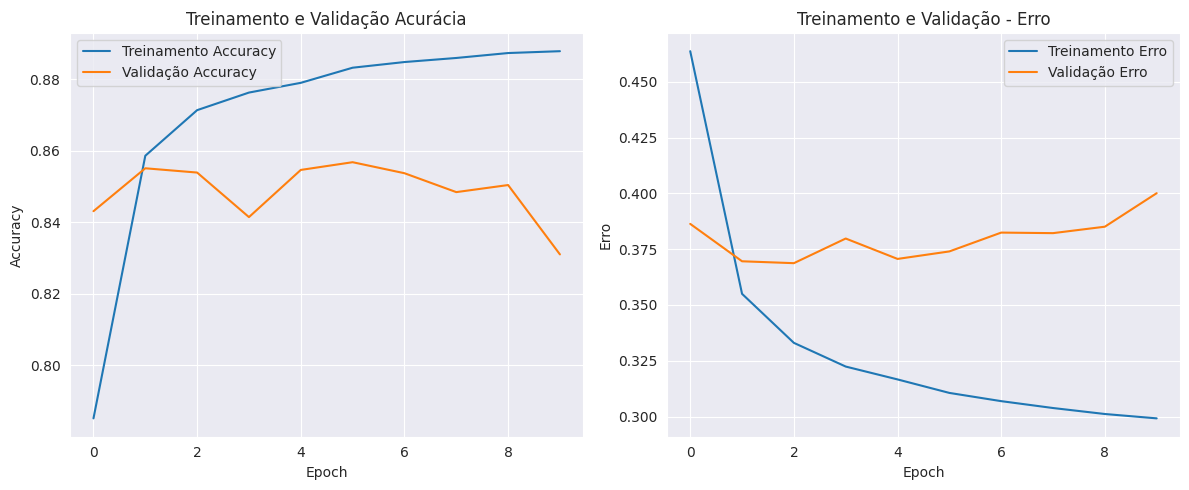

Test Erro: 0.4001
Test Accuracy: 0.8310


In [151]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treinamento Accuracy')
plt.plot(history.history['val_accuracy'], label='Validação Accuracy')
plt.title('Treinamento e Validação Acurácia')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treinamento Erro')
plt.plot(history.history['val_loss'], label='Validação Erro')
plt.title('Treinamento e Validação - Erro')
plt.xlabel('Epoch')
plt.ylabel('Erro')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Erro: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

### Análise dos Resultados do Modelo de Deep Learning

Os gráficos acima ilustram o desempenho do modelo de Deep Learning durante o treinamento e a validação. O gráfico de acurácia mostra como a precisão do modelo se desenvolveu em ambos os conjuntos, enquanto o gráfico de perda (loss) indica quão bem o modelo está aprendendo e ajustando seus pesos para minimizar o erro.

**Pontos Chave:**
*   **Acurácia de Treinamento (Training Accuracy):** Reflete o quão bem o modelo se ajusta aos dados de treinamento.
*   **Acurácia de Validação (Validation Accuracy):** Indica a capacidade de generalização do modelo para dados não vistos. Uma diferença significativa entre a acurácia de treinamento e validação pode sugerir overfitting.
*   **Erro de Treinamento (Training Loss):** Mede o erro do modelo nos dados de treinamento.
*   **Erro de Validação (Validation Loss):** Mede o erro do modelo nos dados de validação, sendo um bom indicador de quão bem o modelo performa em novos dados.

Além dos gráficos, o resultado da avaliação final no conjunto de teste fornece a acurácia e a perda que o modelo alcança em um conjunto de dados completamente novo, confirmando sua performance generalizada.

##11 Análise das Dores dos Clientes

### 11.1 Análise das reclamações negativas

In [152]:
complaints_by_product = df_label['product'].value_counts().reset_index()
complaints_by_product.columns = ['Produto', 'Quantidade de Reclamações']
print("Quantidade de Reclamações por Produto:")
display(complaints_by_product)

Quantidade de Reclamações por Produto:


,Produto,Quantidade de Reclamações
0,credit_reporting,48011
1,debt_collection,17883
2,mortgages_and_loans,17520
3,credit_card,13857
4,retail_banking,11562


In [153]:
df_negativo=df_label[df_label['label']==0].copy()

In [154]:
df_negativo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48873 entries, 1 to 162412
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product              48873 non-null  object
 1   tokens               48873 non-null  object
 2   narrative_processed  48873 non-null  object
 3   sentimento_textblob  48873 non-null  object
 4   label                48873 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.2+ MB


In [155]:
negative_complaints_by_product = df_negativo['product'].value_counts().reset_index()
negative_complaints_by_product.columns = ['Produto', 'Quantidade de Reclamações Negativas']
print("Quantidade de Reclamações Negativas por Produto:")
display(negative_complaints_by_product)

Quantidade de Reclamações Negativas por Produto:


,Produto,Quantidade de Reclamações Negativas
0,credit_reporting,22852
1,mortgages_and_loans,7893
2,debt_collection,6993
3,credit_card,6128
4,retail_banking,5007


In [156]:
df_merged = pd.merge(complaints_by_product,
                     negative_complaints_by_product,
                     on='Produto',
                     how='left')

df_merged['% Reclamações Negativas'] = (df_merged['Quantidade de Reclamações Negativas'] / df_merged['Quantidade de Reclamações']) * 100

print("Análise de Reclamações por Produto:")
display(df_merged.round(2))

Análise de Reclamações por Produto:


,Produto,Quantidade de Reclamações,Quantidade de Reclamações Negativas,% Reclamações Negativas
0,credit_reporting,48011,22852,47.60
1,debt_collection,17883,6993,39.10
2,mortgages_and_loans,17520,7893,45.05
3,credit_card,13857,6128,44.22
4,retail_banking,11562,5007,43.31


Credit Card -- Cartão de Crédito
Retail Banking -- Banco de varejo
Credit Reporting -- Informações de crédito
Mortgages and loans -- Hipotecas e empréstimos
Debt Collection -- Cobrança de Dívidas

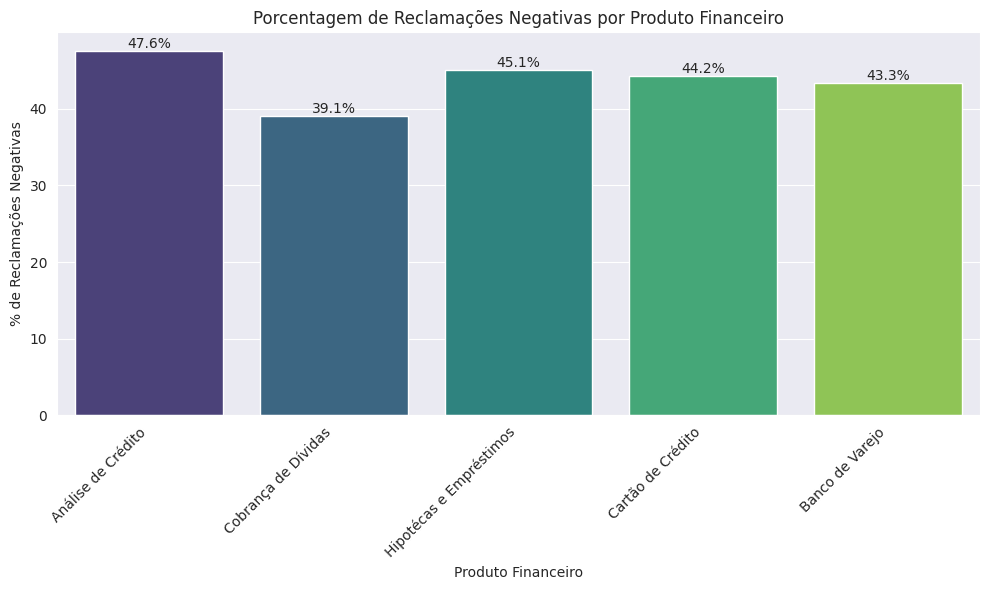

In [162]:
product_name_mapping = {
    'credit_reporting': 'Análise de Crédito',
    'debt_collection': 'Cobrança de Dívidas',
    'mortgages_and_loans': 'Hipotécas e Empréstimos',
    'credit_card': 'Cartão de Crédito',
    'retail_banking': 'Banco de Varejo'
}

df_merged_renamed = df_merged.copy()
df_merged_renamed['Produto'] = df_merged_renamed['Produto'].replace(product_name_mapping)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Produto', y='% Reclamações Negativas', data=df_merged_renamed, ax=ax, palette='viridis')
ax.set_title('Porcentagem de Reclamações Negativas por Produto Financeiro')
ax.set_xlabel('Produto Financeiro')
ax.set_ylabel('% de Reclamações Negativas')

# Adicionar rótulos de porcentagem nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

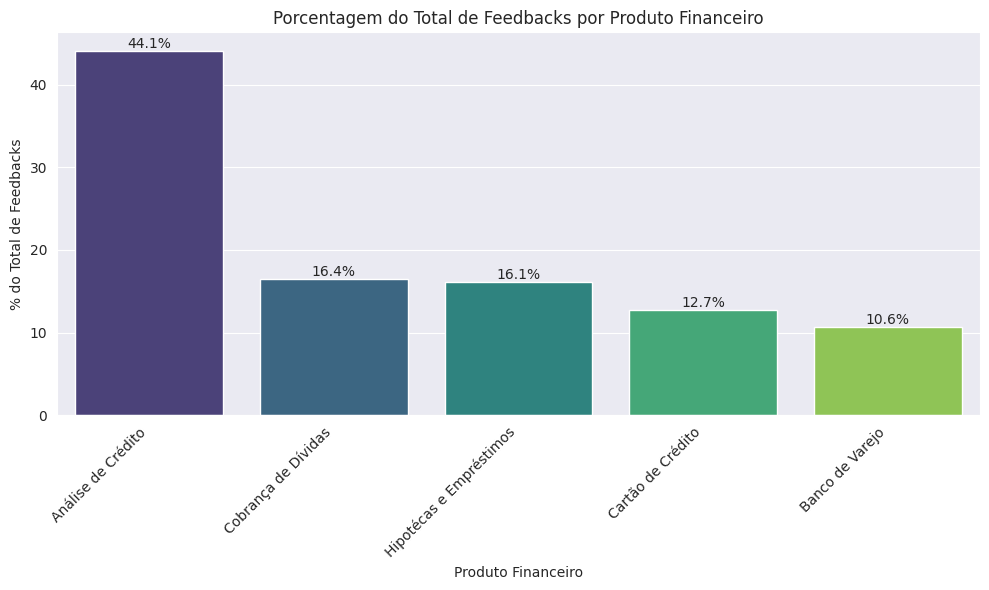

In [171]:
total_complaints_overall = df_merged_renamed['Quantidade de Reclamações'].sum()
df_merged_renamed['% Total Reclamações'] = (df_merged_renamed['Quantidade de Reclamações'] / total_complaints_overall) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Produto', y='% Total Reclamações', data=df_merged_renamed, ax=ax, palette='viridis')
ax.set_title('Porcentagem do Total de Feedbacks por Produto Financeiro')
ax.set_xlabel('Produto Financeiro')
ax.set_ylabel('% do Total de Feedbacks')

# Adicionar rótulos de porcentagem nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###11.2 Análises das principais queixas por produto

In [157]:
def plot_top_words_by_product (product_name, ax):
  subset = df_negativo[df_negativo['product'] == product_name]
  if subset.empty:
    ax.set_title(f'Nenhuma reclamação negativa para: {product_name}')
    ax.set_visible(False) # Hide the subplot if no data
    return

  vec = CountVectorizer(ngram_range=(1,2), max_features=15)
  try:
    bow = vec.fit_transform(subset['narrative_processed'])
    sum_words = bow.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    #Plot
    words, counts = zip(*words_freq)
    sns.barplot(x=list(counts), y=list(words), ax=ax, palette='viridis')
    for container in ax.containers:
        ax.bar_label(container, fmt='%d') # Iterate through containers to label all bars
    ax.set_title(f'Principais Queixas: {product_name}')
  except ValueError:
    ax.set_title(f'Sem palavras suficientes para {product_name}')
    ax.set_visible(False) # Hide the subplot if no data

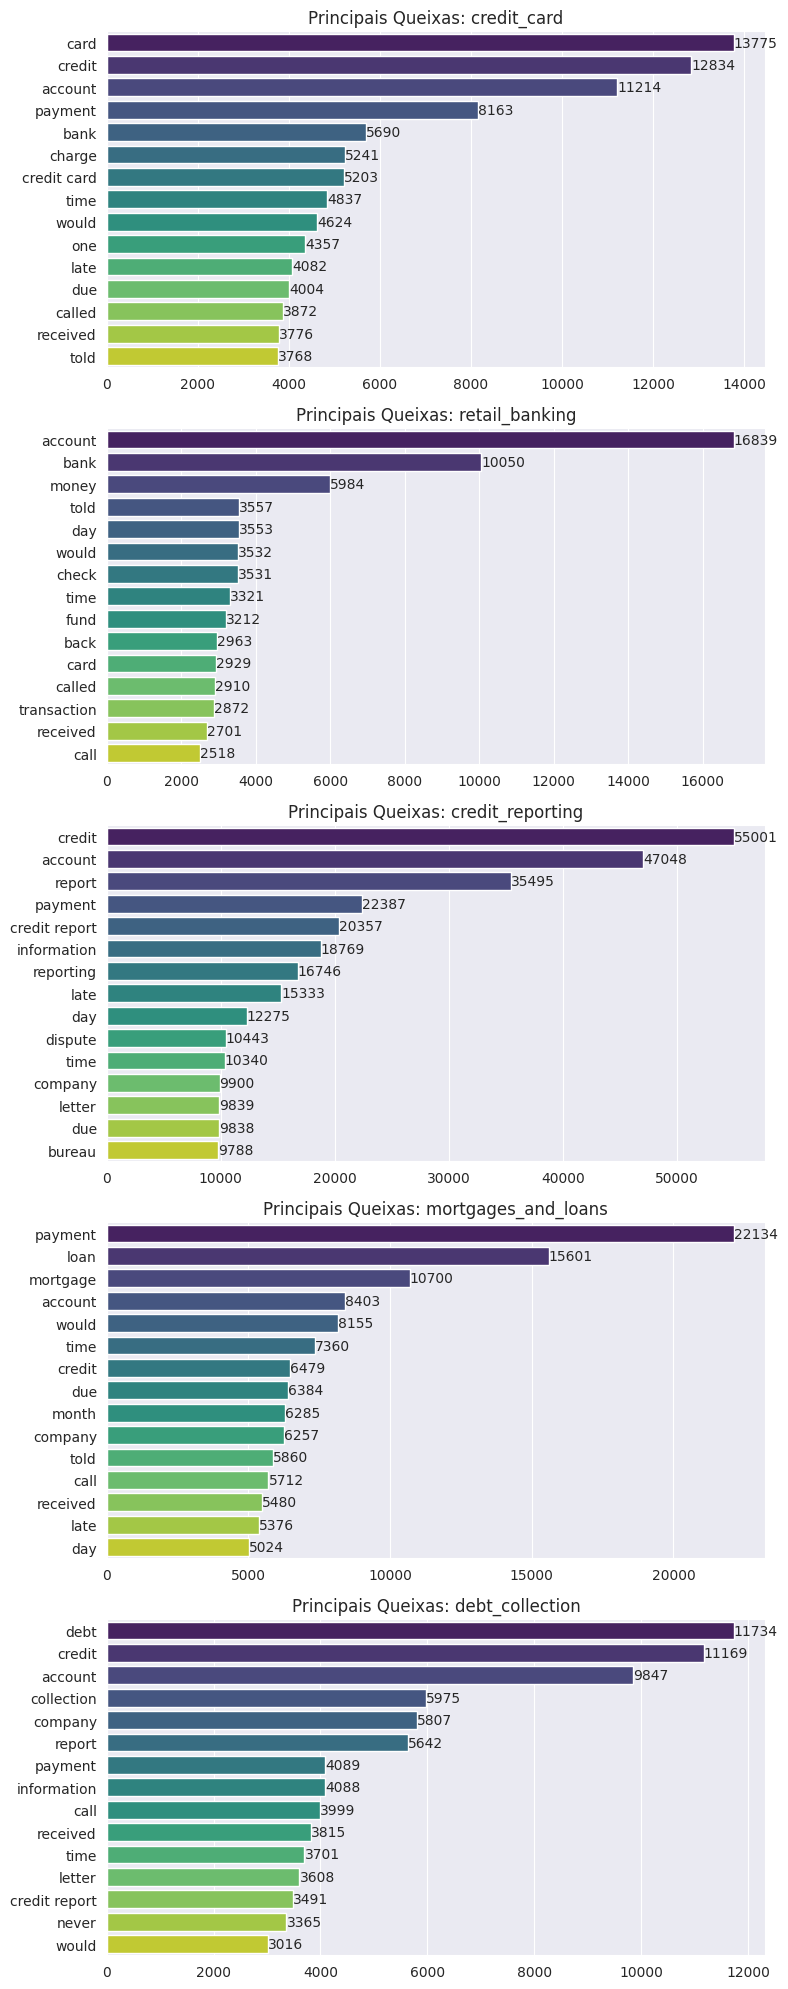

In [158]:
unique_products = df_negativo['product'].unique()
fig, axes= plt.subplots(len(unique_products), 1, figsize=(8, 4 * len(unique_products)))

if len(unique_products) == 1:
  axes = [axes]

for ax, produto in zip(axes, unique_products):
  plot_top_words_by_product(produto, ax)

plt.tight_layout()
plt.show()

###11.3 Nuvem de Palavras por Produto

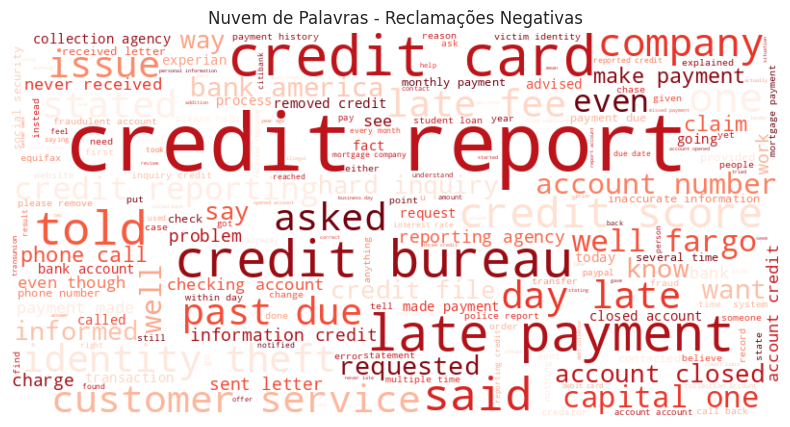

In [159]:
negative_text=" ".join(df_negativo['narrative_processed'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras - Reclamações Negativas')
plt.show()

In [160]:
def generate_wordcloud_by_product(product_name, ax):
    subset = df_negativo[df_negativo['product'] == product_name]
    if subset.empty:
        ax.set_title(f'Nenhuma reclamação negativa para: {product_name}')
        ax.axis('off') # Hide the subplot if no data
        return

    text = " ".join(subset['narrative_processed'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=50).generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Nuvem de Palavras - {product_name}', fontsize=16) # Increased font size for the title

print("Function `generate_wordcloud_by_product` defined.")

Function `generate_wordcloud_by_product` defined.


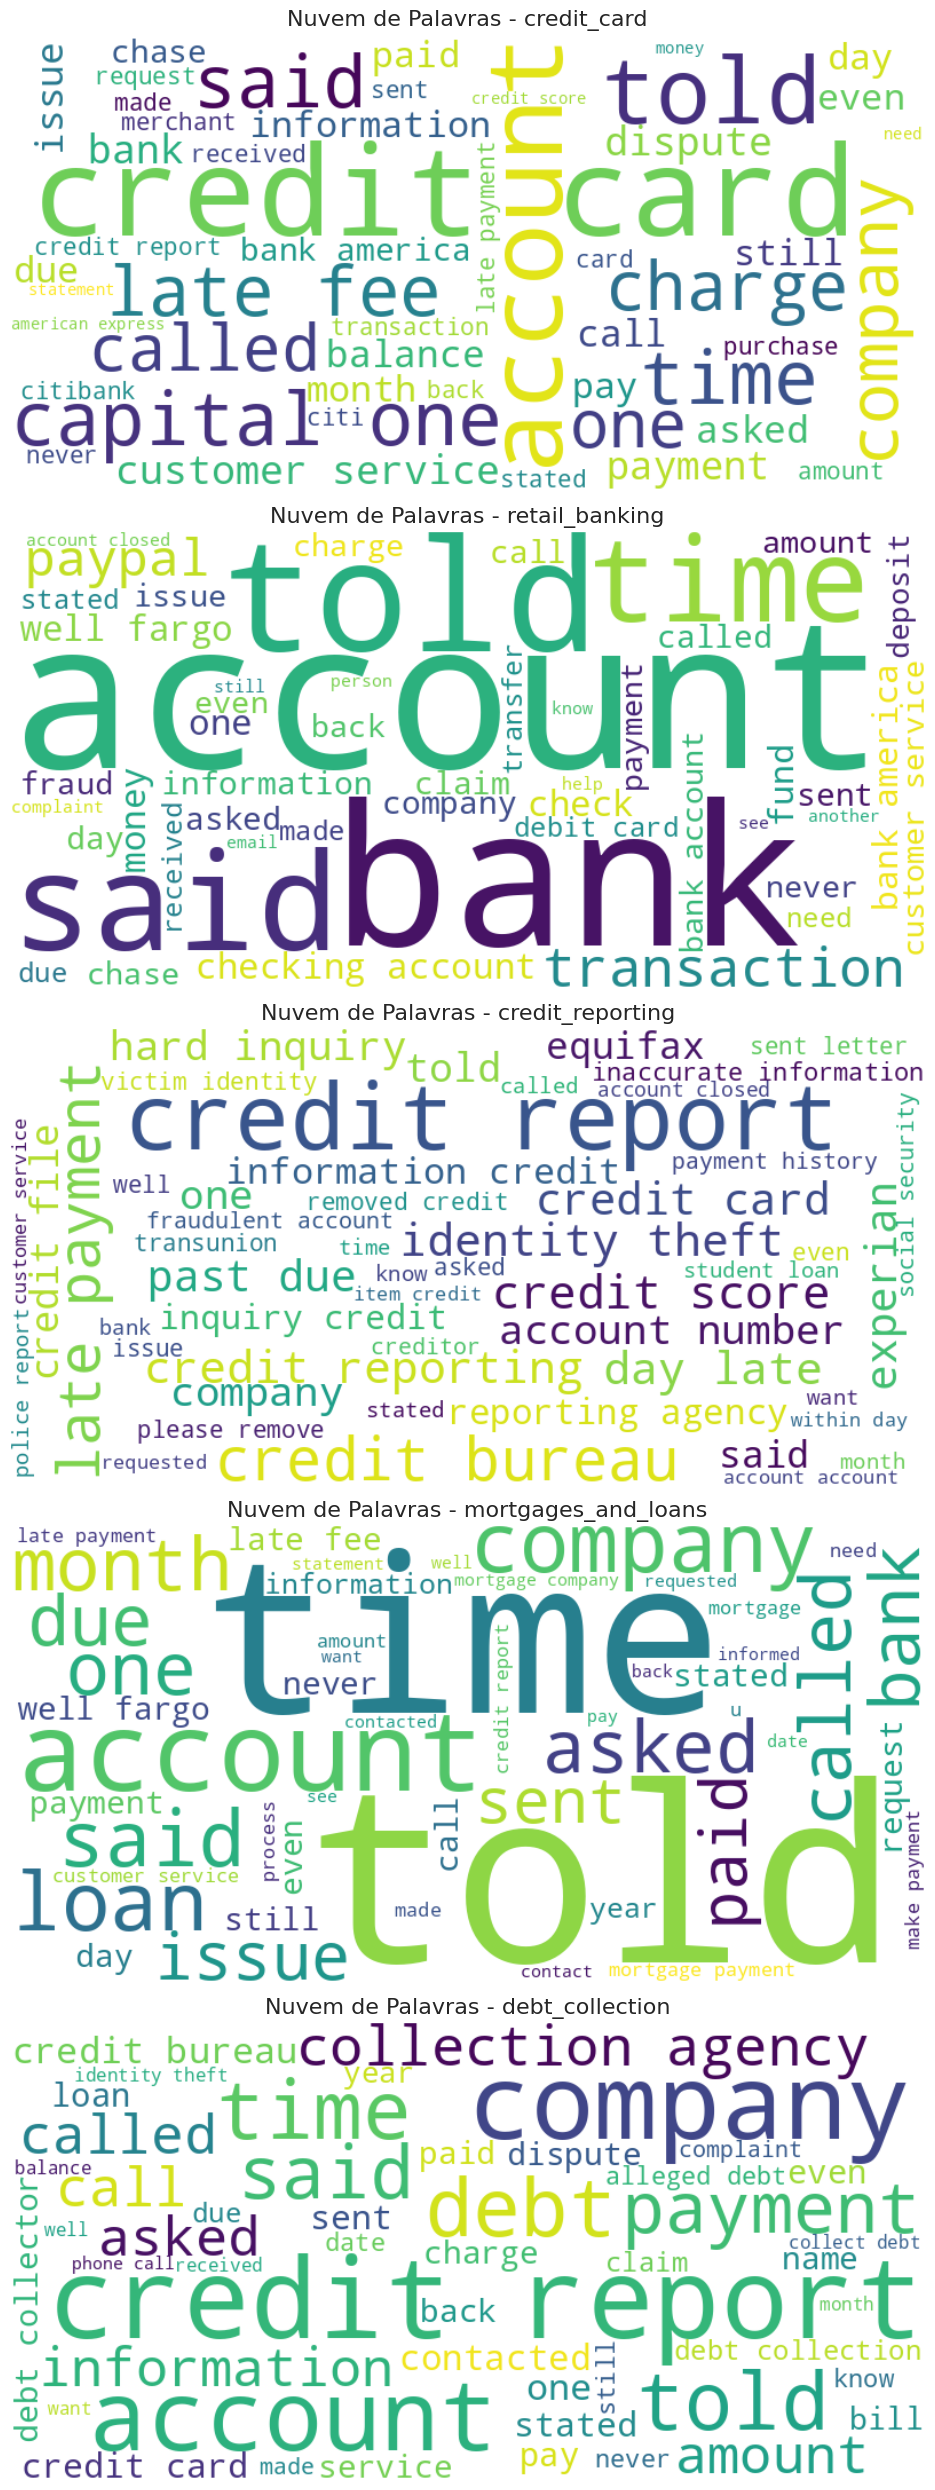

In [161]:
unique_products = df_negativo['product'].unique()

# Calculate the number of rows for subplots dynamically
num_rows = len(unique_products)

fig, axes = plt.subplots(num_rows, 1, figsize=(10, 5 * num_rows))

# Ensure 'axes' is an array even if there's only one subplot
if num_rows == 1:
    axes = [axes]

for ax, product_name in zip(axes, unique_products):
    generate_wordcloud_by_product(product_name, ax)

plt.tight_layout()
plt.show()

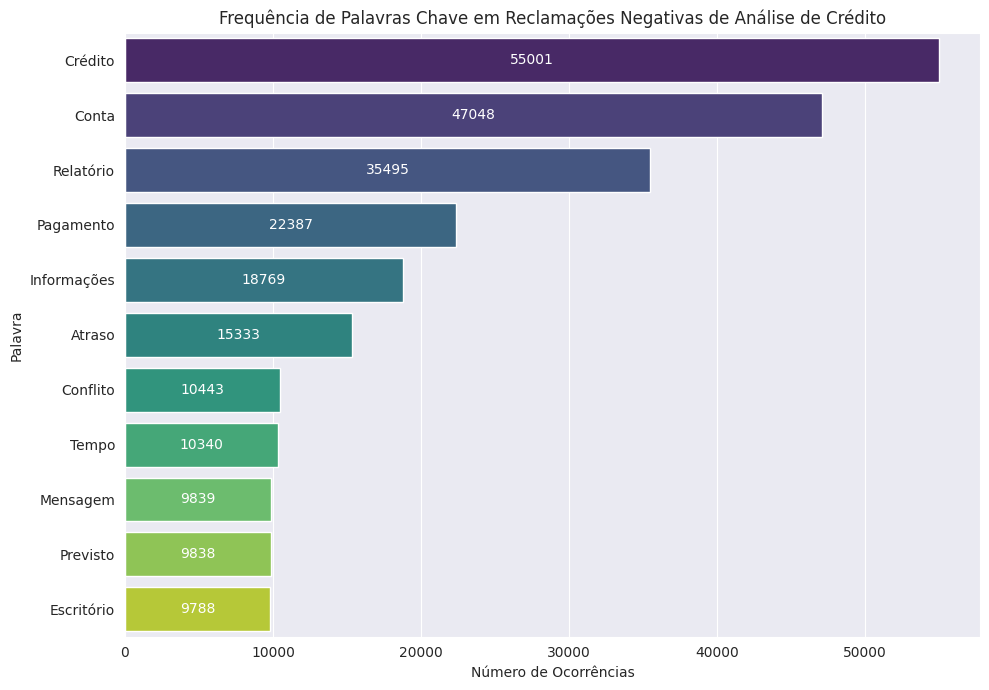

In [169]:
product_name = 'credit_reporting'
credit_reporting_df = df_negativo[df_negativo['product'] == product_name]

# Palavras a serem analisadas e seus novos nomes
word_mapping = {
    'credit': 'Crédito',
    'account': 'Conta',
    'report': 'Relatório',
    'payment': 'Pagamento',
    'information': 'Informações',
    'late': 'Atraso',
    'dispute': 'Conflito',
    'time': 'Tempo',
    'letter': 'Mensagem',
    'due': 'Previsto',
    'bureau': 'Escritório'
}

# Filtrar tokens e contar a frequência apenas das palavras desejadas
all_tokens_credit_reporting = [token for sublist in credit_reporting_df['narrative_processed'].apply(lambda x: x.split())
                               for token in sublist if token in word_mapping.keys()]

word_counts = Counter(all_tokens_credit_reporting)

# Criar DataFrame para o gráfico
plot_df = pd.DataFrame(word_counts.items(), columns=['Palavra', 'Contagem'])
plot_df['Palavra'] = plot_df['Palavra'].map(word_mapping) # Aplicar a tradução
plot_df = plot_df.sort_values(by='Contagem', ascending=False)

# Criar o gráfico de barras
plt.figure(figsize=(10, 7))
ax = sns.barplot(x='Contagem', y='Palavra', data=plot_df, palette='viridis')
plt.title(f'Frequência de Palavras Chave em Reclamações Negativas de {product_name_mapping[product_name]}')
plt.xlabel('Número de Ocorrências')
plt.ylabel('Palavra')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='center', color='white') # Corrigido para 'center'
plt.tight_layout()
plt.show()

### Discussing Insights from Word Clouds by Product

The word clouds generated for each financial product (Credit Card, Retail Banking, Credit Reporting, Mortgages and Loans, and Debt Collection) provide valuable insights into the specific pains and common terms associated with negative customer experiences in each category.

**Key Observations:**

*   **Credit Card:** Common terms likely include 'fraud', 'charge', 'account', 'limit', 'payment', 'fee', indicating issues related to unauthorized transactions, billing discrepancies, account management, and fees.
*   **Retail Banking:** Terms such as 'account', 'bank', 'service', 'fee', 'money', 'transaction' might highlight problems with account access, customer service, unexpected charges, and incorrect transactions.
*   **Credit Reporting:** This category would probably show words like 'report', 'credit', 'score', 'error', 'information', 'inquiry', suggesting complaints around inaccuracies in credit reports, negative impacts on credit scores, and issues with information reporting or unauthorized inquiries.
*   **Mortgages and Loans:** Expect to see terms such as 'loan', 'payment', 'mortgage', 'home', 'interest', 'rate', 'escrow', indicating concerns about loan terms, payment processing, interest rates, and escrow account management.
*   **Debt Collection:** Words like 'debt', 'collection', 'call', 'company', 'harassment', 'payment', 'agency' would likely point to issues with aggressive collection practices, disputed debts, communication problems with collection agencies, and payment arrangements.

These word clouds visually summarize the most frequent and impactful terms, allowing stakeholders to quickly grasp the core problems in each product area and prioritize improvements or interventions.

Resumo do trabalho realizado:

1. Limpeza e Pré-processamento dos Dados:

Carregamos o dataset de reclamações financeiras.
Removemos linhas com narrative nula e duplicatas.
Aplicamos tokenização, lowercasing, remoção de pontuação e caracteres especiais, remoção de stopwords e stemming (radicalização) aos textos das reclamações.

2. Criação da Variável Alvo (Sentimento):

Experimentamos dois métodos para classificar o sentimento (Positivo/Negativo/Neutro):
Método Manual (palavras-chave): Definimos listas de palavras-chave positivas e negativas (e expandimos as listas após análise de termos neutros).
TextBlob: Utilizamos a biblioteca TextBlob para análise de polaridade, que se mostrou mais eficaz para nossa base (menor quantidade de neutros).
Criamos a coluna label (1 para Positivo, 0 para Negativo) usando os resultados do TextBlob e removemos os casos neutros para os modelos.

3. Modelagem de Classificação:

Vetorização TF-IDF: Convertemos o texto processado em representações numéricas usando TF-IDF.
Modelos Tradicionais:
Naive Bayes (MultinomialNB): Alcançou uma acurácia de 73%.
XGBoost: Apresentou uma acurácia superior de 89%.
Modelo de Deep Learning (Keras Sequential Model):
Preparamos os dados com Tokenizer e pad_sequences.
Construímos um modelo com camadas de Embedding, GlobalAveragePooling1D e Dense.
Treinamos o modelo por 10 épocas e alcançamos uma acurácia de teste de aproximadamente 85.42%.
Discutimos o impacto do batch size e do número de epochs no treinamento.

4. Análise das Dores dos Clientes:

Geramos uma tabela com a quantidade total e percentual de reclamações negativas por produto, mostrando que 'Credit Reporting' tem o maior volume de reclamações negativas.
Geramos gráficos de barras com as principais queixas por produto, com rótulos de quantidade em cada barra para melhor visualização das frequências.
Criamos nuvens de palavras para cada produto para visualizar os termos mais frequentes nas reclamações negativas e identificar as "dores" específicas dos clientes em cada categoria financeira.